# LIAR Dataset

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
import torch

import warnings
warnings.filterwarnings("ignore")

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\Laura GALINDO\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [3]:
# Chargement des données
columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 
    'state', 'party', 'barely_true', 'false', 'half_true', 
    'mostly_true', 'pants_on_fire', 'context'
]

df = pd.read_csv('liar_dataset/test.tsv', sep='\t', header=None, names=columns)

## Analyse Exploratoire des Données

Nombre de lignes : 1267
                            speaker       party  \
0                        rick-perry  republican   
1                 katrina-shankland    democrat   
2                      donald-trump  republican   
3                     rob-cornilles  republican   
4  state-democratic-party-wisconsin    democrat   

                                           statement       label  
0  Building a wall on the U.S.-Mexico border will...        true  
1  Wisconsin is on pace to double the number of l...       false  
2  Says John McCain has done nothing to help the ...       false  
3  Suzanne Bonamici supports a plan that will cut...   half-true  
4  When asked by a reporter whether hes at the ce...  pants-fire  


id               object
label            object
statement        object
subject          object
speaker          object
speaker_job      object
state            object
party            object
barely_true       int64
false             int64
half_true         int64
m

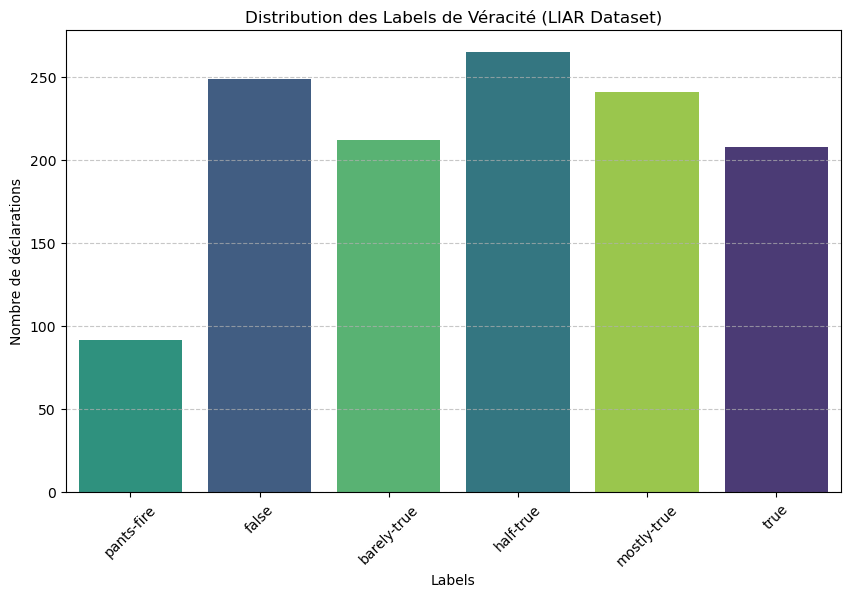

In [5]:
# Aperçu rapide
print(f"Nombre de lignes : {len(df)}")
print(df[['speaker', 'party', 'statement', 'label']].head())
print('\n')
print(df.dtypes)

# Valeurs manquantes
missing_values = df.isnull().sum()
print('\n')
print(f"Nombre de valeurs manquantes : \n{missing_values[missing_values > 0]}")

# Doublons
nb_duplicates = df.duplicated().sum()
print('\n')
print(f"Nombre de lignes en double : {nb_duplicates}")

# Visualisation de la distribution des labels
print('\n')
plt.figure(figsize=(10, 6))
order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
sns.countplot(data=df, x='label', order=order, palette='viridis', hue='label', legend=False)
plt.title('Distribution des Labels de Véracité (LIAR Dataset)')
plt.xlabel('Labels')
plt.ylabel('Nombre de déclarations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preprocessing

### Gestion des valeurs manquantes

In [8]:
# On remplace les NaN par 'unknown'
cols_to_fix = ['speaker_job', 'state', 'context']

for col in cols_to_fix:
    df[col] = df[col].fillna('unknown')

# Vérification
print(df[cols_to_fix].isnull().sum())

speaker_job    0
state          0
context        0
dtype: int64


### Gestion du déséquilibre des classes (Mappage des Labels)

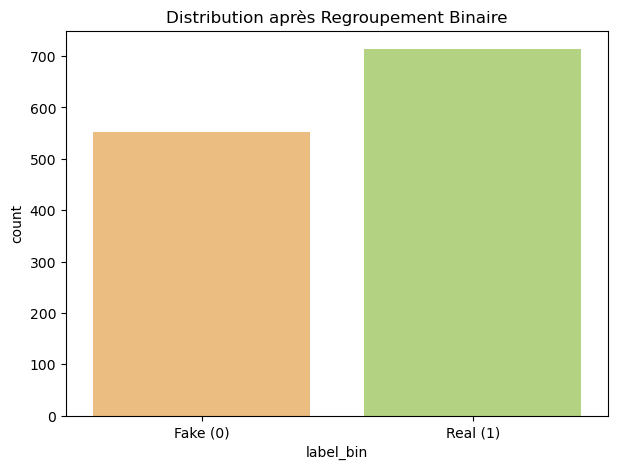

Proportions après regroupement :
label_bin
1    0.563536
0    0.436464
Name: proportion, dtype: float64


In [10]:
# Définition du dictionnaire de correspondance (Mapping)
# On regroupe les catégories de doute/mensonge vs les catégories de vérité
binary_map = {
    'pants-fire': 0, 
    'false': 0, 
    'barely-true': 0,
    'half-true': 1, 
    'mostly-true': 1, 
    'true': 1
}

# Création de la nouvelle colonne
df['label_bin'] = df['label'].map(binary_map)

# Vérification de la nouvelle distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label_bin', hue='label_bin', palette='RdYlGn', legend=False)
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.title('Distribution après Regroupement Binaire')
plt.show()

print("Proportions après regroupement :")
print(df['label_bin'].value_counts(normalize=True))

In [29]:
# Sélection des colonnes numériques (Historique + Label Binaire)
# On inclut le label_bin pour voir ce qui influence la décision
numeric_cols = [
    'barely_true', 'false', 'half_true', 'mostly_true', 
    'pants_on_fire', 'label_bin'
]

# Calcul de la matrice de corrélation
corr_matrix = df[numeric_cols].corr()

# Affichage de la Heatmap
plt.figure(figsize=(10, 8))

# On utilise un masque pour ne voir que la partie basse (plus lisible)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,      # Affiche les chiffres
            fmt=".2f",       # 2 décimales
            cmap='coolwarm', # Bleu (négatif) à Rouge (positif)
            center=0, 
            linewidths=.5)

plt.title('Corrélation entre l\'historique du locuteur et la véracité (Label Binaire)')
plt.show()

NameError: name 'np' is not defined

<Figure size 1000x800 with 0 Axes>

### Nettoyage et tokenisation

In [12]:
# Téléchargements nécessaires
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Mise en minuscule
    text = text.lower()
    # Suppression de la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenisation
    tokens = word_tokenize(text)
    # Suppression des stopwords
    cleaned_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

# Application sur le dataframe (colonne 'statement')
df['cleaned_statement'] = df['statement'].apply(clean_text)

print(df[['statement', 'cleaned_statement']].head())

                                           statement  \
0  Building a wall on the U.S.-Mexico border will...   
1  Wisconsin is on pace to double the number of l...   
2  Says John McCain has done nothing to help the ...   
3  Suzanne Bonamici supports a plan that will cut...   
4  When asked by a reporter whether hes at the ce...   

                                   cleaned_statement  
0  building wall usmexico border take literally y...  
1          wisconsin pace double number layoffs year  
2            says john mccain done nothing help vets  
3  suzanne bonamici supports plan cut choice medi...  
4  asked reporter whether hes center criminal sch...  


[nltk_data] Downloading package punkt to C:\Users\Laura
[nltk_data]     GALINDO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Laura
[nltk_data]     GALINDO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Feature Engineering

#### TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=5000) # On limite aux 5000 mots les plus importants
X_tfidf = tfidf.fit_transform(df['cleaned_statement']).toarray()

print(f"Forme de la matrice TF-IDF : {X_tfidf.shape}")

#### Embeddings (Word2Vec / GloVe)

In [ ]:
# On travaille sur des listes de mots pour Word2Vec
sentences = [row.split() for row in df['cleaned_statement']]

# Entraînement d'un modèle Word2Vec simple
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Fonction pour obtenir le vecteur moyen d'une phrase
import numpy as np
def get_sentence_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([get_sentence_vector(s, w2v_model) for s in sentences])

#### Embeddings Contextuels (BERT / RoBERTa)

In [ ]:
# Chargement du modèle (DistilBERT est plus rapide pour un Notebook)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

def get_bert_embeddings(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # On prend le vecteur du token [CLS] (représentation de la phrase)
    return outputs.last_hidden_state[:, 0, :].numpy()

# Note : C'est lent sur CPU. À faire sur un échantillon pour tester.
# sample_embeddings = get_bert_embeddings(df['statement'].iloc[0])